<a href="https://colab.research.google.com/github/94Akriti/DL-ML-USING-PYTORCH/blob/main/Custom_Datasets.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Pytorch - Using Torchvision for Images

Domain Libraries: based on the input file type whether it is image, video, text, audio Pytorch provide domain libraries which has dataloader functions and customizable data loading functions

In [303]:
import torch
from torch import nn

torch.__version__

'2.11.0+cu128'

In [304]:
device = "cuda" if torch.cuda.is_available() else"cpu"
device

'cuda'

## Get Data

Subset of Food101 dataset

We will work on dataset with 3 classes of food only and then gradually increase the data to 750 training 250 testing dataset

In [305]:
import requests
import zipfile
from pathlib import Path

data_path  = Path("data/")
image_path = data_path / "pizza_steak_sushi"

if image_path.is_dir():
    print(f"{image_path} directory exists------skipping download")
else:
    print(f" {image_path} does not exist, creating one...")
    image_path.mkdir(parents=True, exist_ok = True)


with open(data_path / "pizza_steak_sushi.zip","wb") as f:
  request = requests.get("https://github.com/mrdbourke/pytorch-deep-learning/raw/main/data/pizza_steak_sushi.zip")
  print("Downloading pizza, steak, sushi data...")
  f.write(request.content)
with zipfile.ZipFile(data_path / "pizza_steak_sushi.zip","r") as zip_ref:
  print("Unzipping pizza, steak, and sushi data...")
  zip_ref.extractall(image_path)

data/pizza_steak_sushi directory exists------skipping download
Unzipping pizza, steak, and sushi data...


## Data Preparation and exploration

In [306]:
import os
def walk_through_dir(dir_path):
  for dirpath, dirnames, filenames in os.walk(dir_path):
    print(f"There are {len(dirnames)} directories and {len(filenames)} images in {dirpath}")
walk_through_dir(image_path)


There are 2 directories and 0 images in data/pizza_steak_sushi
There are 3 directories and 0 images in data/pizza_steak_sushi/train
There are 0 directories and 75 images in data/pizza_steak_sushi/train/steak
There are 0 directories and 72 images in data/pizza_steak_sushi/train/sushi
There are 0 directories and 78 images in data/pizza_steak_sushi/train/pizza
There are 3 directories and 0 images in data/pizza_steak_sushi/test
There are 0 directories and 19 images in data/pizza_steak_sushi/test/steak
There are 0 directories and 31 images in data/pizza_steak_sushi/test/sushi
There are 0 directories and 25 images in data/pizza_steak_sushi/test/pizza


In [307]:
train_dir = image_path / "train"
test_dir = image_path / "test"
train_dir,test_dir

(PosixPath('data/pizza_steak_sushi/train'),
 PosixPath('data/pizza_steak_sushi/test'))

## Visualize the images

* Get all the image paths
* Pick random image path using Python's random.choice()
* Get image class name using pathlib.Path.parent.stem
* Using Python's PIL the images can be opened
* show images and print metadata

### Using PIL

Random Image Path: data/pizza_steak_sushi/train/sushi/700405.jpg
 Image Class:sushi
Image size: 384
 Image width: 512


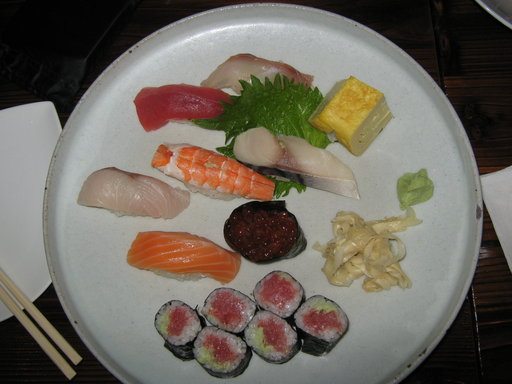

In [308]:
import random
from PIL import Image

# random.seed(42)

image_path_list = list(image_path.glob("*/*/*.jpg"))
random_image_path = random.choice(image_path_list)
print(f"Random Image Path: {random_image_path}")

image_class = random_image_path.parent.stem
print(f" Image Class:{image_class}")

img = Image.open(random_image_path)
print(f"Image size: {img.height}")
print(f" Image width: {img.width}")
img

### Using Matplotlib

(np.float64(-0.5), np.float64(511.5), np.float64(383.5), np.float64(-0.5))

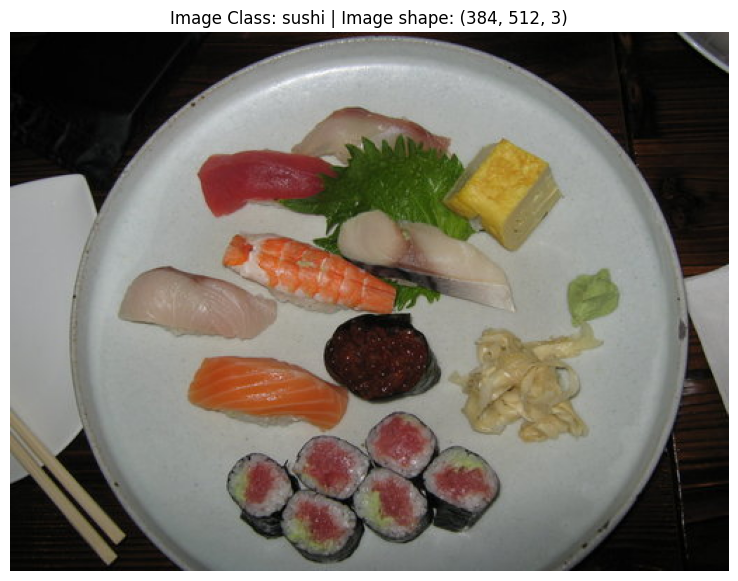

In [309]:
import numpy as np
import matplotlib.pyplot as plt

image_as_array = np.asarray(img)

plt.figure(figsize=(10,7))
plt.imshow(image_as_array)
plt.title(f"Image Class: {image_class} | Image shape: {image_as_array.shape}")
plt.axis(False)

array([[[ 3,  3,  1],
        [ 3,  3,  1],
        [ 3,  3,  1],
        ...,
        [85, 80, 76],
        [87, 82, 78],
        [88, 83, 79]],

       [[ 6,  6,  4],
        [ 6,  6,  4],
        [ 6,  6,  4],
        ...,
        [83, 78, 74],
        [84, 79, 75],
        [85, 80, 76]],

       [[ 8,  8,  6],
        [ 8,  8,  6],
        [ 8,  8,  6],
        ...,
        [80, 77, 72],
        [82, 77, 73],
        [82, 77, 73]],

       ...,

       [[ 7,  7,  5],
        [ 7,  7,  5],
        [ 7,  7,  5],
        ...,
        [ 3,  3,  3],
        [ 3,  3,  3],
        [ 3,  3,  3]],

       [[ 5,  5,  3],
        [ 5,  5,  3],
        [ 5,  5,  3],
        ...,
        [ 3,  3,  3],
        [ 3,  3,  3],
        [ 3,  3,  3]],

       [[ 5,  5,  3],
        [ 5,  5,  3],
        [ 5,  5,  3],
        ...,
        [ 2,  2,  2],
        [ 2,  2,  2],
        [ 2,  2,  2]]], dtype=uint8)
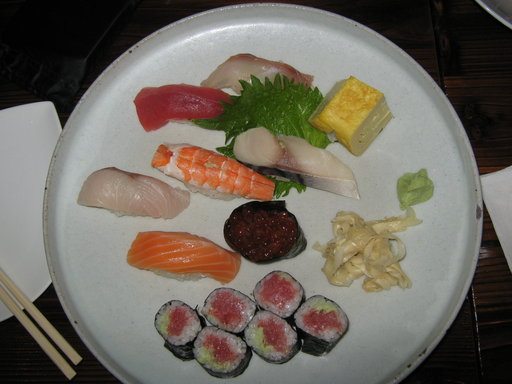

In [310]:
image_as_array

## Transforming data

To utilize image data in Pytorch models we require to follow below standard steps:

1. turn target data into tensors
2. Transform the tensors into torch.utils.data.Dataset and then torch.utils.data.DataLoader using Dataset and DataLoader.

### Transforming data using torchvision.transforms

Transforms is used to convert image data into tensors that can be readily used for our PyTorch models data augmentation

In [311]:
import torch
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
# convert jpeg images to tensors

data_transform = transforms.Compose([
    transforms.Resize(size = (64,64)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.ToTensor()
    ])

In [312]:
data_transform(img).shape

torch.Size([3, 64, 64])

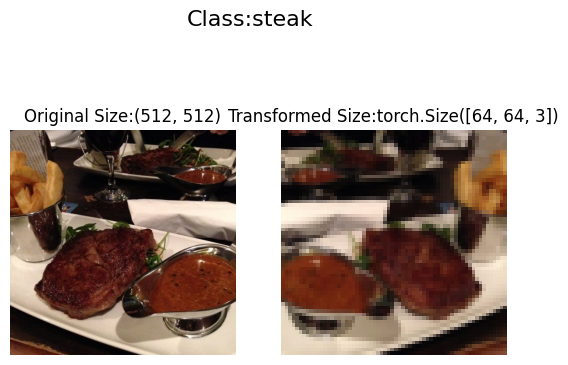

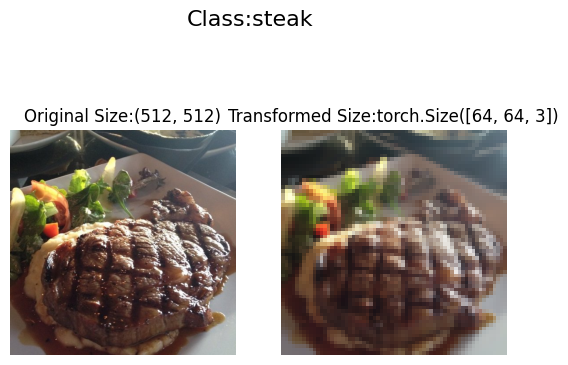

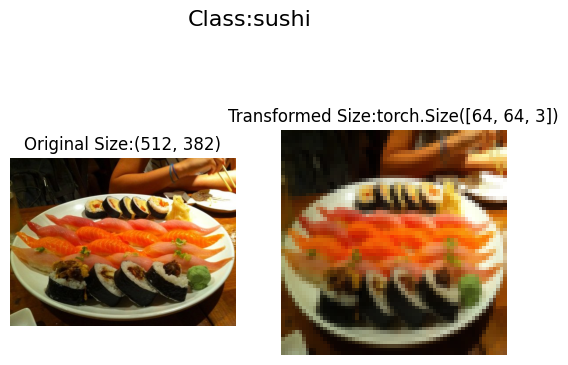

In [313]:
def plot_transformed_images(image_paths, transform, n=3, seed=42):
  random.seed(seed)
  random_image_paths = random.sample(image_paths, k=n)
  for image_path in random_image_paths:
    with Image.open(image_path) as f:
      fig, ax = plt.subplots(nrows=1,ncols=2)
      ax[0].imshow(f)
      ax[0].set_title(f"Original Size:{f.size}")
      ax[0].axis("off")
      transformed_image = transform(f).permute(1,2,0)# permute is used to change order (C,H,W)-(H,W,C) for matplotlib
      ax[1].imshow(transformed_image)
      ax[1].set_title(f"Transformed Size:{transformed_image.shape}")
      ax[1].axis("off")
      fig.suptitle(f"Class:{image_path.parent.stem}", fontsize=16)

plot_transformed_images(image_paths = image_path_list,
                        transform=data_transform,
                        n=3,
                        seed=42)

## Loading images using ImageFolder



In [314]:
from torchvision import datasets
train_data = datasets.ImageFolder(root=train_dir,
                                    transform=data_transform,
                                    target_transform=None)
test_data = datasets.ImageFolder(root=test_dir,
                                    transform=data_transform,
                                    target_transform=None)
print(f"Train data:{train_data}, \nTest data:{test_data}")
print(f"Length of train data: {len(train_data)},\nLength of Test data:{len(test_data)}")
print(f"Train directory:{train_dir} , \nTest directory: {test_dir}")

Train data:Dataset ImageFolder
    Number of datapoints: 225
    Root location: data/pizza_steak_sushi/train
    StandardTransform
Transform: Compose(
               Resize(size=(64, 64), interpolation=bilinear, max_size=None, antialias=True)
               RandomHorizontalFlip(p=0.5)
               ToTensor()
           ), 
Test data:Dataset ImageFolder
    Number of datapoints: 75
    Root location: data/pizza_steak_sushi/test
    StandardTransform
Transform: Compose(
               Resize(size=(64, 64), interpolation=bilinear, max_size=None, antialias=True)
               RandomHorizontalFlip(p=0.5)
               ToTensor()
           )
Length of train data: 225,
Length of Test data:75
Train directory:data/pizza_steak_sushi/train , 
Test directory: data/pizza_steak_sushi/test


In [315]:
class_names = train_data.classes

In [316]:
class_names

['pizza', 'steak', 'sushi']

In [317]:
class_dict = train_data.class_to_idx
class_dict

{'pizza': 0, 'steak': 1, 'sushi': 2}

In [318]:
train_data[0]

(tensor([[[0.1137, 0.1020, 0.0980,  ..., 0.1255, 0.1216, 0.1176],
          [0.1059, 0.0980, 0.0980,  ..., 0.1294, 0.1294, 0.1294],
          [0.1020, 0.0980, 0.0941,  ..., 0.1333, 0.1333, 0.1333],
          ...,
          [0.1098, 0.1098, 0.1255,  ..., 0.1686, 0.1647, 0.1686],
          [0.0902, 0.0941, 0.1098,  ..., 0.1686, 0.1647, 0.1686],
          [0.0863, 0.0863, 0.0980,  ..., 0.1686, 0.1647, 0.1647]],
 
         [[0.0745, 0.0706, 0.0745,  ..., 0.0588, 0.0588, 0.0588],
          [0.0745, 0.0706, 0.0745,  ..., 0.0627, 0.0627, 0.0627],
          [0.0706, 0.0745, 0.0745,  ..., 0.0706, 0.0706, 0.0706],
          ...,
          [0.1255, 0.1333, 0.1373,  ..., 0.2510, 0.2392, 0.2392],
          [0.1098, 0.1176, 0.1255,  ..., 0.2510, 0.2392, 0.2314],
          [0.1020, 0.1059, 0.1137,  ..., 0.2431, 0.2353, 0.2275]],
 
         [[0.0941, 0.0902, 0.0902,  ..., 0.0157, 0.0196, 0.0196],
          [0.0902, 0.0863, 0.0902,  ..., 0.0196, 0.0157, 0.0196],
          [0.0902, 0.0902, 0.0902,  ...,

In [319]:
img,label = train_data[0][0], train_data[0][1]
img
print(f"Image tensor:\n{img}")
print(f"Image shape: {img.shape}")
print(f"Label: {label}, Class: {class_names[label]}")
print(f"Label datatype:{type(label)}")

Image tensor:
tensor([[[0.1176, 0.1216, 0.1255,  ..., 0.0980, 0.1020, 0.1137],
         [0.1294, 0.1294, 0.1294,  ..., 0.0980, 0.0980, 0.1059],
         [0.1333, 0.1333, 0.1333,  ..., 0.0941, 0.0980, 0.1020],
         ...,
         [0.1686, 0.1647, 0.1686,  ..., 0.1255, 0.1098, 0.1098],
         [0.1686, 0.1647, 0.1686,  ..., 0.1098, 0.0941, 0.0902],
         [0.1647, 0.1647, 0.1686,  ..., 0.0980, 0.0863, 0.0863]],

        [[0.0588, 0.0588, 0.0588,  ..., 0.0745, 0.0706, 0.0745],
         [0.0627, 0.0627, 0.0627,  ..., 0.0745, 0.0706, 0.0745],
         [0.0706, 0.0706, 0.0706,  ..., 0.0745, 0.0745, 0.0706],
         ...,
         [0.2392, 0.2392, 0.2510,  ..., 0.1373, 0.1333, 0.1255],
         [0.2314, 0.2392, 0.2510,  ..., 0.1255, 0.1176, 0.1098],
         [0.2275, 0.2353, 0.2431,  ..., 0.1137, 0.1059, 0.1020]],

        [[0.0196, 0.0196, 0.0157,  ..., 0.0902, 0.0902, 0.0941],
         [0.0196, 0.0157, 0.0196,  ..., 0.0902, 0.0863, 0.0902],
         [0.0196, 0.0157, 0.0157,  ..., 0.09

In [320]:
class_names[label]

'pizza'

Original shape:torch.Size([3, 64, 64])
Image permute shape:torch.Size([64, 64, 3])


(np.float64(-0.5), np.float64(63.5), np.float64(63.5), np.float64(-0.5))

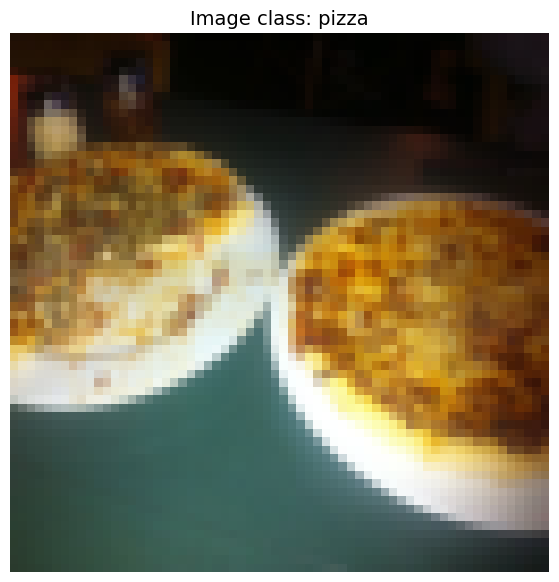

In [321]:
image_permute=  img.permute(1,2,0)

print(f"Original shape:{img.shape}")
print(f"Image permute shape:{image_permute.shape}")

plt.figure(figsize=(10,7))
plt.imshow(image_permute)
plt.title(f"Image class: {class_names[label]}",fontsize=14)
plt.axis("off")

### Turn loaded images to dataloader

DataLoader is used to convert the dataset into iterable form so it can be customized into batches

In [322]:
import os
from torch.utils.data import DataLoader
print(os.cpu_count())# total cores used by the cpu/gpu to run this program
BATCH_SIZE =1
train_dataloader = DataLoader(dataset = train_data,
                              batch_size=BATCH_SIZE,# split complete dataset into batches to reduce ram load
                              num_workers=1,# total number of cores of the cpu required
                              shuffle = True)

test_dataloader = DataLoader(dataset = test_data,
                             batch_size = BATCH_SIZE,
                             num_workers = 1,
                             shuffle = False)

print(f"Train dataloader:\n{train_dataloader}, \nTest Dataloader:\n{test_dataloader}")

2
Train dataloader:
Test Dataloader:


In [323]:
print("We have Batchsize set to 1 so both data and dataloader length will be same")
# size of the data loaded in dataloader gets divided into number of batches provided currenly 225/1 = 225
print(f"Original Train data lenght:{len(train_data)}, Train Dataloader length: {len(train_dataloader)},\nOriginal Test Data length:{len(test_data)}, Test DataLoader Length:{len(test_dataloader)}")

We have Batchsize set to 1 so both data and dataloader length will be same
Original Train data lenght:225, Train Dataloader length: 225,
Original Test Data length:75, Test DataLoader Length:75


In [324]:
img,label = next(iter(train_dataloader))# iterate over the dataloader to load images per batch, label represent the each batch, here we set batch size = 1 so we get 1 label

print(f"Image shape: {img.shape}")
print(f"Label shape:{label.shape}")

Image shape: torch.Size([1, 3, 64, 64])
Label shape:torch.Size([1])


# Loading image data with custom Dataset

A custom dataset can be used to load images from files, fetch class names from the dataset, get lasses in form of a dictionery from the dataset

Custom Dataset is easy to create and it is not limited to PyTorch's in-built libraries.

All custom datasets are subclass to torch.utils.data.dataset

In [325]:
import os
import pathlib
import torch
from PIL import Image
from torch.utils.data import Dataset
from torchvision import transforms
from typing import Tuple,Dict, List

In [326]:
train_data.classes, train_data.class_to_idx

(['pizza', 'steak', 'sushi'], {'pizza': 0, 'steak': 1, 'sushi': 2})

## Creating Helper fucntion to get class name


We will be using os.scandir() to traverse through the target file

Make error handler if the class is not found

Return class names in form of dictionary

In [327]:
target_directory = train_dir

print(f"Target dir: {target_directory}")

class_names_found = sorted([entry.name for entry in list(os.scandir(target_directory))])
print(f"Classes Found at {target_directory}: {class_names_found}")


Target dir: data/pizza_steak_sushi/train
Classes Found at data/pizza_steak_sushi/train: ['pizza', 'steak', 'sushi']


In [328]:

def find_classes(directory: str) -> Tuple[List[str], Dict[str,int]]:
  classes = sorted(entry.name for entry in os.scandir(directory) if entry.is_dir())
  if not classes:
    raise FileNotFoundError(f"Couldn't find any class in {directory}")

  class_to_idx = {cls_name:i for i,cls_name in enumerate(classes)}
  return classes,class_to_idx


In [329]:
find_classes(target_directory)

(['pizza', 'steak', 'sushi'], {'pizza': 0, 'steak': 1, 'sushi': 2})

## Custom Dataset to replicate ImageFolder

To replicate ImageFolder functionality in our custom Dataset we need to fullfill following steps:

1. subclass torch.utils.data.Dataset

2. Init our subclass with target directory then transform the data

3. Create attributes-
  path, transform, classes, class_to_idx

4. Create function to load imges

5. overwrite __len()__ and __getitem()__ to return length of dataset and returning sample that is passed over an index

### Custom ImageFolder

In [330]:
from torch.utils.data import Dataset

class ImageFolderCustom(Dataset):
  def __init__(self,targ_dir: str, transform=None):
    self.paths = list(pathlib.Path(targ_dir).glob("*/*.jpg"))
    self.transform =  transform #optional
    self.classes, self.class_to_idx = find_classes(targ_dir)

  def load_image(self,index: int) -> Image.Image:
    image_path = self.paths[index]
    return Image.open(image_path)

  # optional overwiting length
  def __len__(self) -> int:
    return len(self.paths)

  # for subclassing torch.utils.data.Dataset this is required for all custom Datasets
  def __getitem__(self,index: int) -> Tuple[torch.Tensor,int]:
    img = self.load_image(index)
    class_name = self.paths[index].parent.name
    class_idx = self.class_to_idx[class_name]

    if self.transform:
      return self.transform(img), class_idx
    else:
      return img, class_idx



### Creating instance of custom ImageFolder

In [331]:
from torchvision import transforms
train_transforms = transforms.Compose([
    transforms.Resize(size=(64,64)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.ToTensor()])
test_transforms = transforms.Compose([
    transforms.Resize(size=(64,64)),
    transforms.ToTensor()
])

In [332]:
train_data_custom = ImageFolderCustom(targ_dir=train_dir,transform=train_transforms)
test_data_custom = ImageFolderCustom(targ_dir=test_dir,transform=test_transforms)

### Testing custom ImageFolder function

In [333]:
train_data_custom, test_data_custom

(<__main__.ImageFolderCustom at 0x7e50110b0e90>,
 <__main__.ImageFolderCustom at 0x7e5013071c70>)

In [334]:
len(train_data),len(train_data_custom)

(225, 225)

In [335]:
len(test_data),len(test_data_custom)

(75, 75)

In [336]:
train_data_custom.classes

['pizza', 'steak', 'sushi']

In [337]:
train_data_custom.class_to_idx

{'pizza': 0, 'steak': 1, 'sushi': 2}

In [338]:
#check for equality between custom ImageFolder and ImageFolder

print(train_data_custom.classes == train_data.classes)
print(test_data_custom.classes==test_data.classes)

True
True


## Create function to display random images

1. Load Dataset and other parameters such as class names and visualize the number of images
2. Set limit to display images as 10
3. Implement random seed for reproducibility
4. list randoom sample indices from the target dataset
5. Setup matplotlib
6. Loop through the random sample images and plot them with matplotlib
7. Make sure the dimensions of our images line up with matplotlib(HWC)

In [339]:
def display_random_images(dataset: torch.utils.data.Dataset,
                          classes:List[str]= None,
                          n:int = 10,
                          display_shape: bool = True,
                          seed: int = None):
  if n>10:
    n = 10
    display_shape = False
    print(f"for display purpose n must be < 10 setting n to 10")

  if seed:
    random.seed(seed)

  random_sample_idx = random.sample(range(len(dataset)),k=n)

  plt.figure(figsize=(16,8))



  for i, targ_sample in enumerate(random_sample_idx):
    targ_image, targ_label = dataset[targ_sample][0], dataset[targ_sample][1]
    # make the dimentions of image so as to support matplotlib i.e. (H,W,C)
    targ_image_adjust = targ_image.permute(1,2,0)
    # plotting the images using matplotlib
    plt.subplot(1,n,i+1)
    plt.imshow(targ_image_adjust)
    plt.axis("off")
    if classes:
      title = f"Class: {classes[targ_label]}"
      if display_shape:
        title = title + f"\nshape: {targ_image_adjust.shape}"
      plt.title(title)

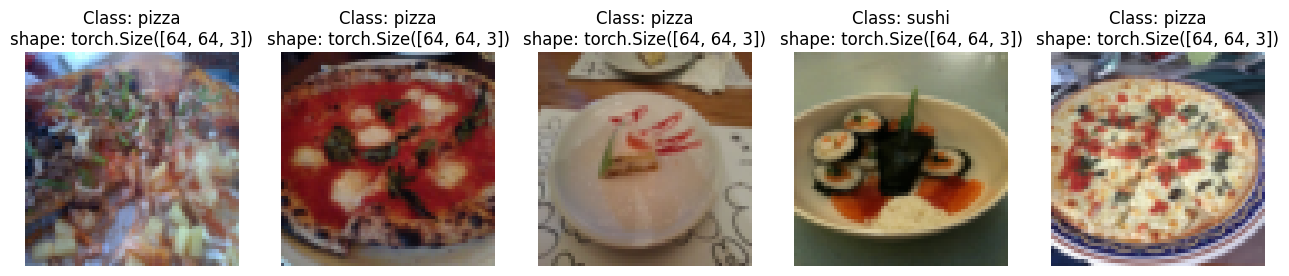

In [340]:
display_random_images(train_data,
                      n= 5,
                      classes= class_names,
                      seed = None)

for display purpose n must be < 10 setting n to 10


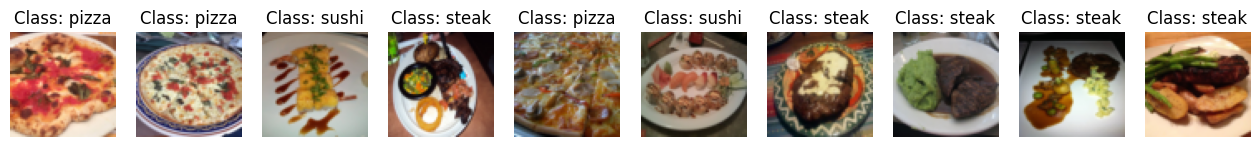

In [341]:
display_random_images(train_data_custom,
                      n= 50,
                      classes= class_names,
                      seed = None)

## Turn custom loaded images to DataLoaders

In [342]:
from torch.utils.data import DataLoader
BATCH_SIZE = 1
NUM_WORKERS = os.cpu_count()
train_dataloader_custom = DataLoader(dataset = train_data_custom,
                                      batch_size = BATCH_SIZE,
                                      num_workers=NUM_WORKERS,
                                      shuffle = True)
test_dataloader_custom = DataLoader(dataset = test_data_custom,
                                     batch_size = BATCH_SIZE,
                                     num_workers=NUM_WORKERS,
                                     shuffle = False)
train_dataloader_custom, test_dataloader_custom


(<torch.utils.data.dataloader.DataLoader at 0x7e50132a5100>,
 <torch.utils.data.dataloader.DataLoader at 0x7e501199eae0>)

In [343]:
img_custom,label_custom = next(iter(train_dataloader_custom))
img_custom.shape, label_custom.shape

(torch.Size([1, 3, 64, 64]), torch.Size([1]))

## Data Augmentation

enhancing existent data for artificially adding diversity to the input data

In [344]:
# Trivial Augment: increase brightness

from torchvision import transforms
train_transform = transforms.Compose([
                                      transforms.Resize(size = (224,224)),
                                      transforms.TrivialAugmentWide(
                                          num_magnitude_bins = 31), #intensity of augmentation intensity
                                      transforms.ToTensor()
                                     ])
test_transform = transforms.Compose([
                                     transforms.Resize(size = (224,224)),
                                     transforms.ToTensor()
                                    ])

In [345]:
# Get all image paths
image_path_list = list(image_path.glob("*/*/*.jpg"))
image_path_list[:10]

[PosixPath('data/pizza_steak_sushi/train/steak/1264154.jpg'),
 PosixPath('data/pizza_steak_sushi/train/steak/3245622.jpg'),
 PosixPath('data/pizza_steak_sushi/train/steak/2614649.jpg'),
 PosixPath('data/pizza_steak_sushi/train/steak/239025.jpg'),
 PosixPath('data/pizza_steak_sushi/train/steak/2707522.jpg'),
 PosixPath('data/pizza_steak_sushi/train/steak/443210.jpg'),
 PosixPath('data/pizza_steak_sushi/train/steak/2825100.jpg'),
 PosixPath('data/pizza_steak_sushi/train/steak/225990.jpg'),
 PosixPath('data/pizza_steak_sushi/train/steak/1615395.jpg'),
 PosixPath('data/pizza_steak_sushi/train/steak/922752.jpg')]

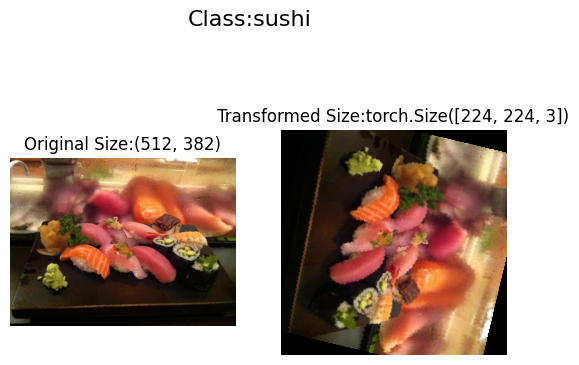

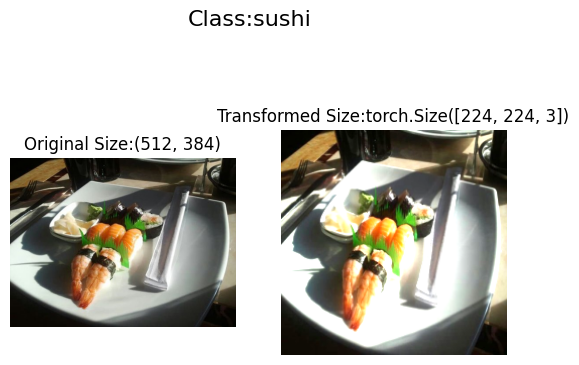

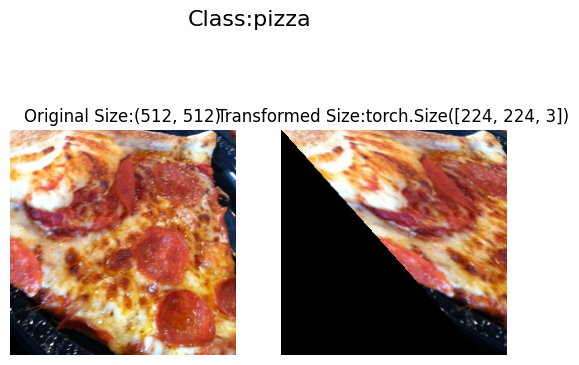

In [346]:
plot_transformed_images(
    image_paths = image_path_list,
    transform = train_transform,
    n = 3,
    seed = None

)

# Model 0: TinyVGG without data augmentation


## Creating Transforms and load the data for Model0

In [347]:
from torchvision import transforms
simple_transform = transforms.Compose([
      transforms.Resize(size=(64,64)),
      transforms.ToTensor()
    ])

### Load data

In [348]:
from torchvision import datasets
train_data_simple = datasets.ImageFolder(root=train_dir,
                                    transform=simple_transform)
test_data_simple = datasets.ImageFolder(root = test_dir,
                                 transform = simple_transform)

In [349]:
import os
from torch.utils.data import DataLoader
BATCH_SIZE = 32
NUM_WORKERS=os.cpu_count()

train_dataloader_simple = DataLoader(dataset = train_data_simple,
                                     batch_size=BATCH_SIZE,
                                     num_workers = NUM_WORKERS,
                                     shuffle = True)
test_dataloader_simple = DataLoader(dataset = test_data_simple,
                                     batch_size=BATCH_SIZE,
                                     num_workers = NUM_WORKERS,
                                     shuffle = False)

## Build Model 0: TinyVGG Model

In [350]:
from torch import nn

class TinyVGGModelSimpleV0(nn.Module):
  """ Model architecture copying TinyVGG from CNN Explainer"""

  def __init__(self, input_shape: int,
               hidden_units: int,
               output_shape: int) -> None:
               super().__init__()
               self.conv_block_1 = nn.Sequential(
                   nn.Conv2d(input_shape,hidden_units,3,1,0),
                   nn.ReLU(),
                   nn.Conv2d(hidden_units,hidden_units,3,1,0),
                   nn.ReLU(),
                   nn.MaxPool2d(2,2)
                   )
               self.conv_block_2 = nn.Sequential(
                   nn.Conv2d(hidden_units,hidden_units,3,1,0),
                   nn.ReLU(),
                   nn.Conv2d(hidden_units,hidden_units,3,1,0),
                   nn.ReLU(),
                   nn.MaxPool2d(2,2)
               )
               self.classifier = nn.Sequential(
                   nn.Flatten(),
                   nn.Linear(hidden_units*13*13,output_shape)
              )
  def forward(self,x):
    # x = self.conv_block_1(x)
    # x = self.conv_block_2(x)
    # x = self.classifier(x)
    # return x
    return self.classifier(self.conv_block_2(self.conv_block_1(x)))


In [351]:
torch.manual_seed(42)
model_0 = TinyVGGModelSimpleV0(3,10,len(class_names)).to(device)
model_0

TinyVGGModelSimpleV0(
  (conv_block_1): Sequential(
    (0): Conv2d(3, 10, kernel_size=(3, 3), stride=(1, 1))
    (1): ReLU()
    (2): Conv2d(10, 10, kernel_size=(3, 3), stride=(1, 1))
    (3): ReLU()
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (conv_block_2): Sequential(
    (0): Conv2d(10, 10, kernel_size=(3, 3), stride=(1, 1))
    (1): ReLU()
    (2): Conv2d(10, 10, kernel_size=(3, 3), stride=(1, 1))
    (3): ReLU()
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=1690, out_features=3, bias=True)
  )
)

## Try forward pass on single image

In [352]:
image_batch, label_batch = next(iter(train_dataloader_simple))
image_batch.shape, label_batch.shape

(torch.Size([32, 3, 64, 64]), torch.Size([32]))

In [353]:
model_0(image_batch.to(device))

tensor([[ 2.0795e-02, -1.9510e-03,  9.5212e-03],
        [ 1.8440e-02,  2.4669e-03,  6.6609e-03],
        [ 1.7695e-02,  1.0282e-03,  9.4975e-03],
        [ 2.4446e-02, -3.3489e-03,  9.5877e-03],
        [ 1.9939e-02,  6.9129e-04,  1.0778e-02],
        [ 2.1281e-02,  2.0434e-03,  5.0046e-03],
        [ 2.0996e-02,  1.6417e-04,  1.2481e-02],
        [ 2.1566e-02, -1.9607e-03,  9.7175e-03],
        [ 2.4500e-02, -4.7904e-03,  8.5394e-03],
        [ 2.0239e-02, -4.7980e-04,  1.0907e-02],
        [ 2.2219e-02, -4.1815e-04,  9.8173e-03],
        [ 2.2318e-02, -2.1642e-03,  9.4428e-03],
        [ 2.1851e-02, -3.7225e-03,  8.3784e-03],
        [ 2.2881e-02, -1.7559e-03,  1.0299e-02],
        [ 2.1635e-02, -4.3994e-03,  9.4990e-03],
        [ 2.2101e-02, -4.1469e-03,  9.3904e-03],
        [ 2.1226e-02, -4.4215e-03,  1.1476e-02],
        [ 2.1698e-02, -2.7458e-03,  8.4966e-03],
        [ 1.9974e-02, -3.2317e-07,  8.4496e-03],
        [ 1.8308e-02,  1.6378e-03,  8.5491e-03],
        [ 2.0768e-02

### `torchinfo` to get shape of data to be used in model

In [354]:
# install torchinfo
try:
  import torchinfo
except:
  !pip install torchinfo
  import torchinfo
from torchinfo import summary

summary(model_0,
        input_size = [1,3,64,64])

Layer (type:depth-idx)                   Output Shape              Param #
TinyVGGModelSimpleV0                     [1, 3]                    --
├─Sequential: 1-1                        [1, 10, 30, 30]           --
│    └─Conv2d: 2-1                       [1, 10, 62, 62]           280
│    └─ReLU: 2-2                         [1, 10, 62, 62]           --
│    └─Conv2d: 2-3                       [1, 10, 60, 60]           910
│    └─ReLU: 2-4                         [1, 10, 60, 60]           --
│    └─MaxPool2d: 2-5                    [1, 10, 30, 30]           --
├─Sequential: 1-2                        [1, 10, 13, 13]           --
│    └─Conv2d: 2-6                       [1, 10, 28, 28]           910
│    └─ReLU: 2-7                         [1, 10, 28, 28]           --
│    └─Conv2d: 2-8                       [1, 10, 26, 26]           910
│    └─ReLU: 2-9                         [1, 10, 26, 26]           --
│    └─MaxPool2d: 2-10                   [1, 10, 13, 13]           --
├─Sequentia

## Create train and test functions

In [355]:
def train_step( model: torch.nn.Module,
               dataloader: torch.utils.data.DataLoader,
               loss_fn: torch.nn.Module,
               optimizer:torch.optim.Optimizer,
               device = device):
  model.train()
  train_loss,train_acc=0,0
  for batch, (X,y) in enumerate(dataloader):
    X,y = X.to(device), y.to(device)
    y_pred = model(X)

    loss = loss_fn(y_pred,y)
    train_loss += loss.item()

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    y_pred_class = torch.argmax(torch.softmax(y_pred,dim=1),dim = 1)
    train_acc += (y_pred_class == y).sum().item()/len(y_pred)

  train_loss = train_loss/len(dataloader)
  train_acc = train_acc/len(dataloader)

  return train_loss,train_acc

In [356]:
def test_step( model: torch.nn.Module,
               dataloader: torch.utils.data.DataLoader,
               loss_fn: torch.nn.Module,
               device = device):
  model.eval()
  test_loss,test_acc=0,0
  with torch.inference_mode():
    for batch,(X,y) in enumerate(dataloader):
      X,y = X.to(device), y.to(device)
      test_pred_logits = model(X)
      loss = loss_fn(test_pred_logits,y)
      test_loss += loss.item()

      test_pred_labels = torch.argmax(torch.softmax(test_pred_logits,dim=1),dim=1)
      test_acc += ((test_pred_labels == y).sum().item()/len(test_pred_labels))

  test_loss = test_loss/len(dataloader)
  test_acc = test_acc/len(dataloader)

  return test_loss,test_acc


## Create `train()` to combine `test_step` and train_step` d

In [357]:
from tqdm.auto import tqdm

#Creating train function with as much as parameters required in train and test functions

def train(model: torch.nn.Module,
          train_dataloader: torch.utils.data.DataLoader,
          test_dataloader: torch.utils.data.DataLoader,
          optimizer: torch.optim.Optimizer,
          loss_fn: torch.nn.Module = nn.CrossEntropyLoss(),
          epochs: int = 5,
          device = device
        ):
  results = {"train_loss":[],
             "train_acc":[],
             "test_loss":[],
             "test_acc":[]
             }
  for epoch in tqdm(range(epochs)):
    train_loss, train_acc = train_step(model = model,
                                       dataloader = train_dataloader,
                                       loss_fn = loss_fn,
                                       optimizer = optimizer,
                                       device = device)
    test_loss, test_acc = test_step(model = model,
                                     dataloader = test_dataloader,
                                     loss_fn = loss_fn,
                                    device= device)
    print(f"Epoch: {epoch} | Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f} | Test Loss: {test_loss:.4f} | Test Acc: {test_acc:.4f}")

    results["train_loss"].append(train_loss)
    results["train_acc"].append(train_acc)
    results["test_loss"].append(test_loss)
    results["test_acc"].append(test_acc)
  return results

## Train and evaluate out TinyVGG model using the train function

In [358]:
torch.manual_seed(42)
torch.cuda.manual_seed(42)


NUM_EPOCHS = 5
model_0 =  TinyVGGModelSimpleV0(3,10,len(class_names)).to(device)

from timeit import default_timer as timer
start_time = timer()
model_0_results = train(model = model_0,
                train_dataloader = train_dataloader_simple,
                test_dataloader = test_dataloader_simple,
                optimizer = torch.optim.Adam(params = model_0.parameters(),lr = 0.001),
                loss_fn = nn.CrossEntropyLoss(),
                epochs = NUM_EPOCHS,
                device = device)

end_time = timer()
print(f"Total Training Time: {end_time-start_time:.3f} seconds")

  0%|          | 0/5 [00:00<?, ?it/s]

Epoch: 0 | Train Loss: 1.1063 | Train Acc: 0.3047 | Test Loss: 1.0983 | Test Acc: 0.3011
Epoch: 1 | Train Loss: 1.0998 | Train Acc: 0.3281 | Test Loss: 1.0697 | Test Acc: 0.5417
Epoch: 2 | Train Loss: 1.0869 | Train Acc: 0.4883 | Test Loss: 1.0808 | Test Acc: 0.4924
Epoch: 3 | Train Loss: 1.0844 | Train Acc: 0.3984 | Test Loss: 1.0607 | Test Acc: 0.5833
Epoch: 4 | Train Loss: 1.0662 | Train Acc: 0.4219 | Test Loss: 1.0655 | Test Acc: 0.5644
Total Training Time: 5.846 seconds


## Visualize Loss curves of our Trained TinyVGG Model

A loss curve is plottings done for tracking our models progress over time

In [359]:
model_0_results.keys()

dict_keys(['train_loss', 'train_acc', 'test_loss', 'test_acc'])

In [360]:
def plot_loss_curves(results: Dict[str,List[float]]):
  loss = results["train_loss"]
  test_loss = results["test_loss"]

  accuracy = results["train_acc"]
  test_accuracy = results["test_acc"]

  epochs = range(len(results["train_loss"]))

  #plot Train aand Test Loss curves
  plt.figure(figsize=(15,7))
  plt.subplot(1,2,1)
  plt.plot(epochs,loss,label="train_loss")
  plt.plot(epochs,test_loss,label="test_loss")
  plt.title("Loss")
  plt.xlabel("Epochs")

  plt.legend()

  # Plot Train Test Accuracy curves
  plt.subplot(1,2,2)
  plt.plot(epochs,accuracy,label="train_accuracy")
  plt.plot(epochs,test_accuracy,label="test_accuracy")
  plt.title("Accuracy")
  plt.xlabel("Epochs")
  plt.legend()

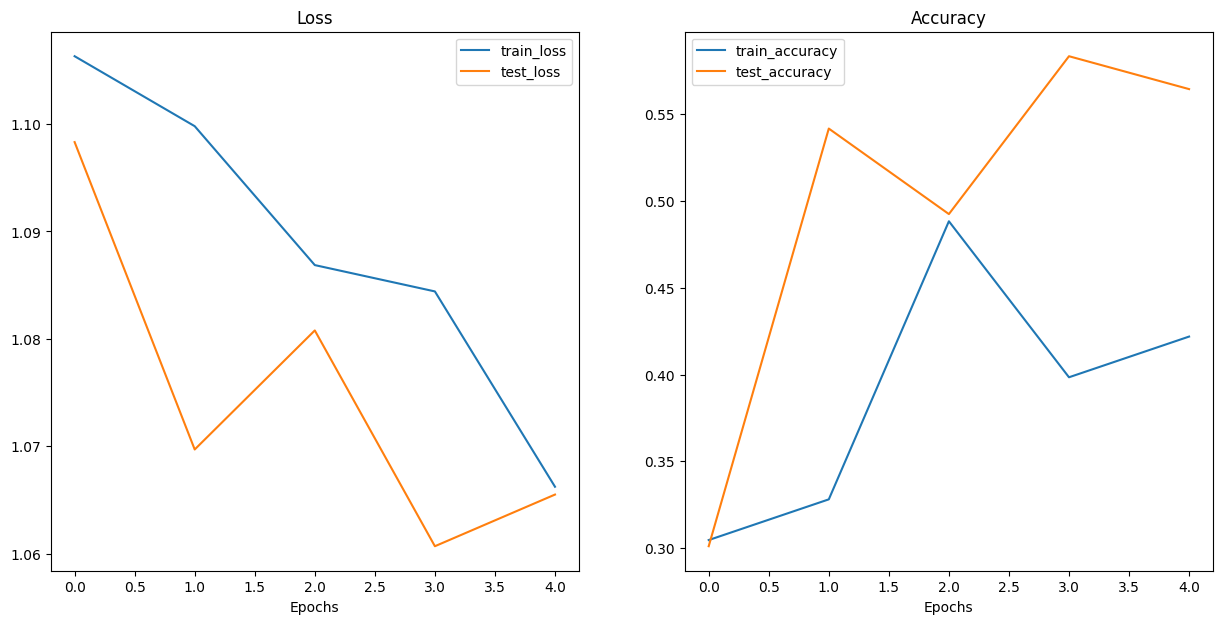

In [361]:
plot_loss_curves(model_0_results)

# MODEL 1: Custom TinyVGG  with data augumentaion

In [362]:
from torchvision import transforms

train_transform_trivial =  transforms.Compose([
    transforms.Resize(size=(64,64)),
    transforms.TrivialAugmentWide(num_magnitude_bins=31),
    transforms.ToTensor()
])

test_transform_trivial = transforms.Compose([
    transforms.Resize(size=(64,64)),
    transforms.ToTensor()
])

In [363]:
from torchvision import datasets

train_data_augumented = datasets.ImageFolder(root=train_dir,
                                             transform=train_transform_trivial)

test_data_augumented = datasets.ImageFolder(root=test_dir,
                                            transform=test_transform_trivial)

## Dataloader over augumented dataset

In [364]:
import os
BATCH_SIZE = 32
NUM_WORKERS = os.cpu_count()

train_dataloader_augumented = DataLoader(dataset=train_data_augumented,
                                          batch_size=BATCH_SIZE,
                                          num_workers=NUM_WORKERS,
                                          shuffle=True)
test_dataloader_augumented = DataLoader(dataset=test_data_augumented,
                                         batch_size=BATCH_SIZE,
                                         num_workers=NUM_WORKERS,
                                         shuffle=False)


In [365]:
torch.manual_seed(42)
torch.cuda.manual_seed(42)

NUM_EPOCHS = 5
model_1 =  TinyVGGModelSimpleV0(3,10,len(train_data_augumented.classes)).to(device)
model_1




TinyVGGModelSimpleV0(
  (conv_block_1): Sequential(
    (0): Conv2d(3, 10, kernel_size=(3, 3), stride=(1, 1))
    (1): ReLU()
    (2): Conv2d(10, 10, kernel_size=(3, 3), stride=(1, 1))
    (3): ReLU()
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (conv_block_2): Sequential(
    (0): Conv2d(10, 10, kernel_size=(3, 3), stride=(1, 1))
    (1): ReLU()
    (2): Conv2d(10, 10, kernel_size=(3, 3), stride=(1, 1))
    (3): ReLU()
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=1690, out_features=3, bias=True)
  )
)

In [366]:
torch.manual_seed(42)
torch.cuda.manual_seed(42)

NUM_EPOCHS = 5
loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(params = model_1.parameters(),lr = 0.001)

from timeit import default_timer as timer
start_time = timer()
model_1_results = train(model = model_1,
                        train_dataloader = train_dataloader_augumented,
                        test_dataloader = test_dataloader_augumented,
                        optimizer=optimizer,
                        loss_fn = loss_fn,
                        epochs=NUM_EPOCHS,
                        device = device)
end_time = timer()

print(f"Total training time for model_1: {end_time-start_time:.3f} seconds")


  0%|          | 0/5 [00:00<?, ?it/s]

Epoch: 0 | Train Loss: 1.1049 | Train Acc: 0.2500 | Test Loss: 1.1019 | Test Acc: 0.2604
Epoch: 1 | Train Loss: 1.0807 | Train Acc: 0.4258 | Test Loss: 1.1260 | Test Acc: 0.2604
Epoch: 2 | Train Loss: 1.0713 | Train Acc: 0.4258 | Test Loss: 1.1593 | Test Acc: 0.2604
Epoch: 3 | Train Loss: 1.1260 | Train Acc: 0.3047 | Test Loss: 1.1583 | Test Acc: 0.2604
Epoch: 4 | Train Loss: 1.0854 | Train Acc: 0.4219 | Test Loss: 1.1547 | Test Acc: 0.3125
Total training time for model_1: 4.992 seconds


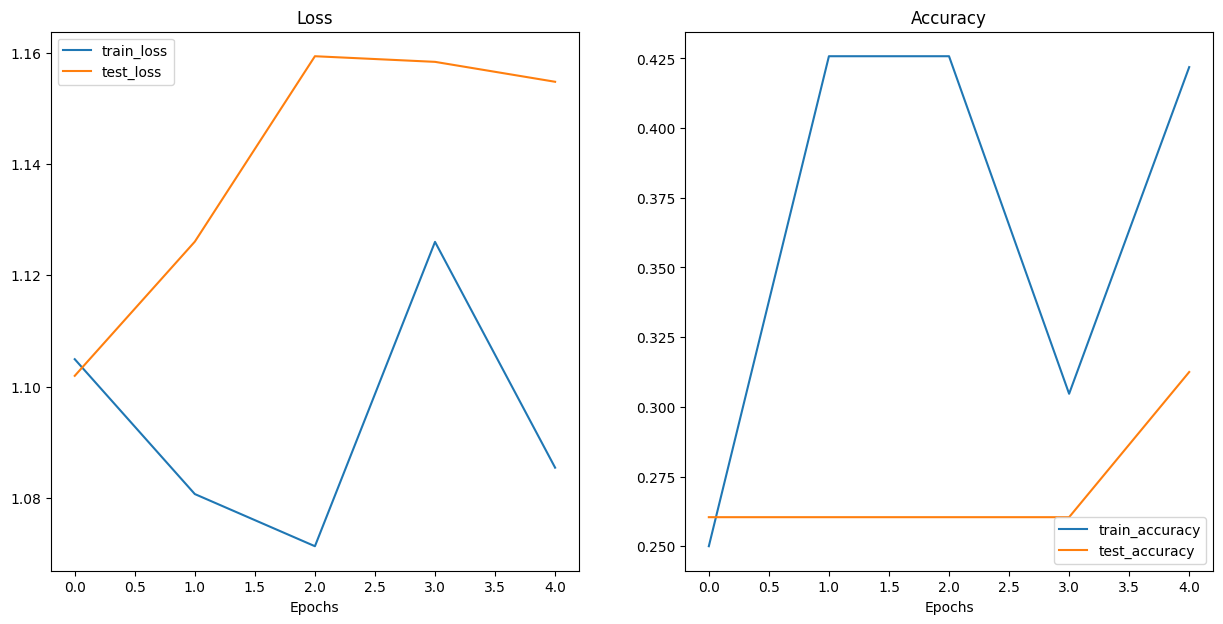

In [367]:
plot_loss_curves(model_1_results)

# Compare `Model0 and Model1` results


To compare the results we can start with following ways:

Hard coding
Tensorboard
Weights and biases
MLFlow

In [368]:
import pandas as pd
model_0_df = pd.DataFrame(model_0_results)
model_1_df = pd.DataFrame(model_1_results)

In [369]:
model_0_df

,train_loss,train_acc,test_loss,test_acc
0,1.106319,0.304688,1.098323,0.301136
1,1.099804,0.328125,1.069696,0.541667
2,1.086868,0.488281,1.080783,0.492424
3,1.084416,0.398438,1.060687,0.583333
4,1.066227,0.421875,1.065498,0.564394


In [370]:
model_1_df

,train_loss,train_acc,test_loss,test_acc
0,1.104914,0.250000,1.101926,0.260417
1,1.080689,0.425781,1.126030,0.260417
2,1.071320,0.425781,1.159334,0.260417
3,1.125990,0.304688,1.158323,0.260417
4,1.085431,0.421875,1.154744,0.312500


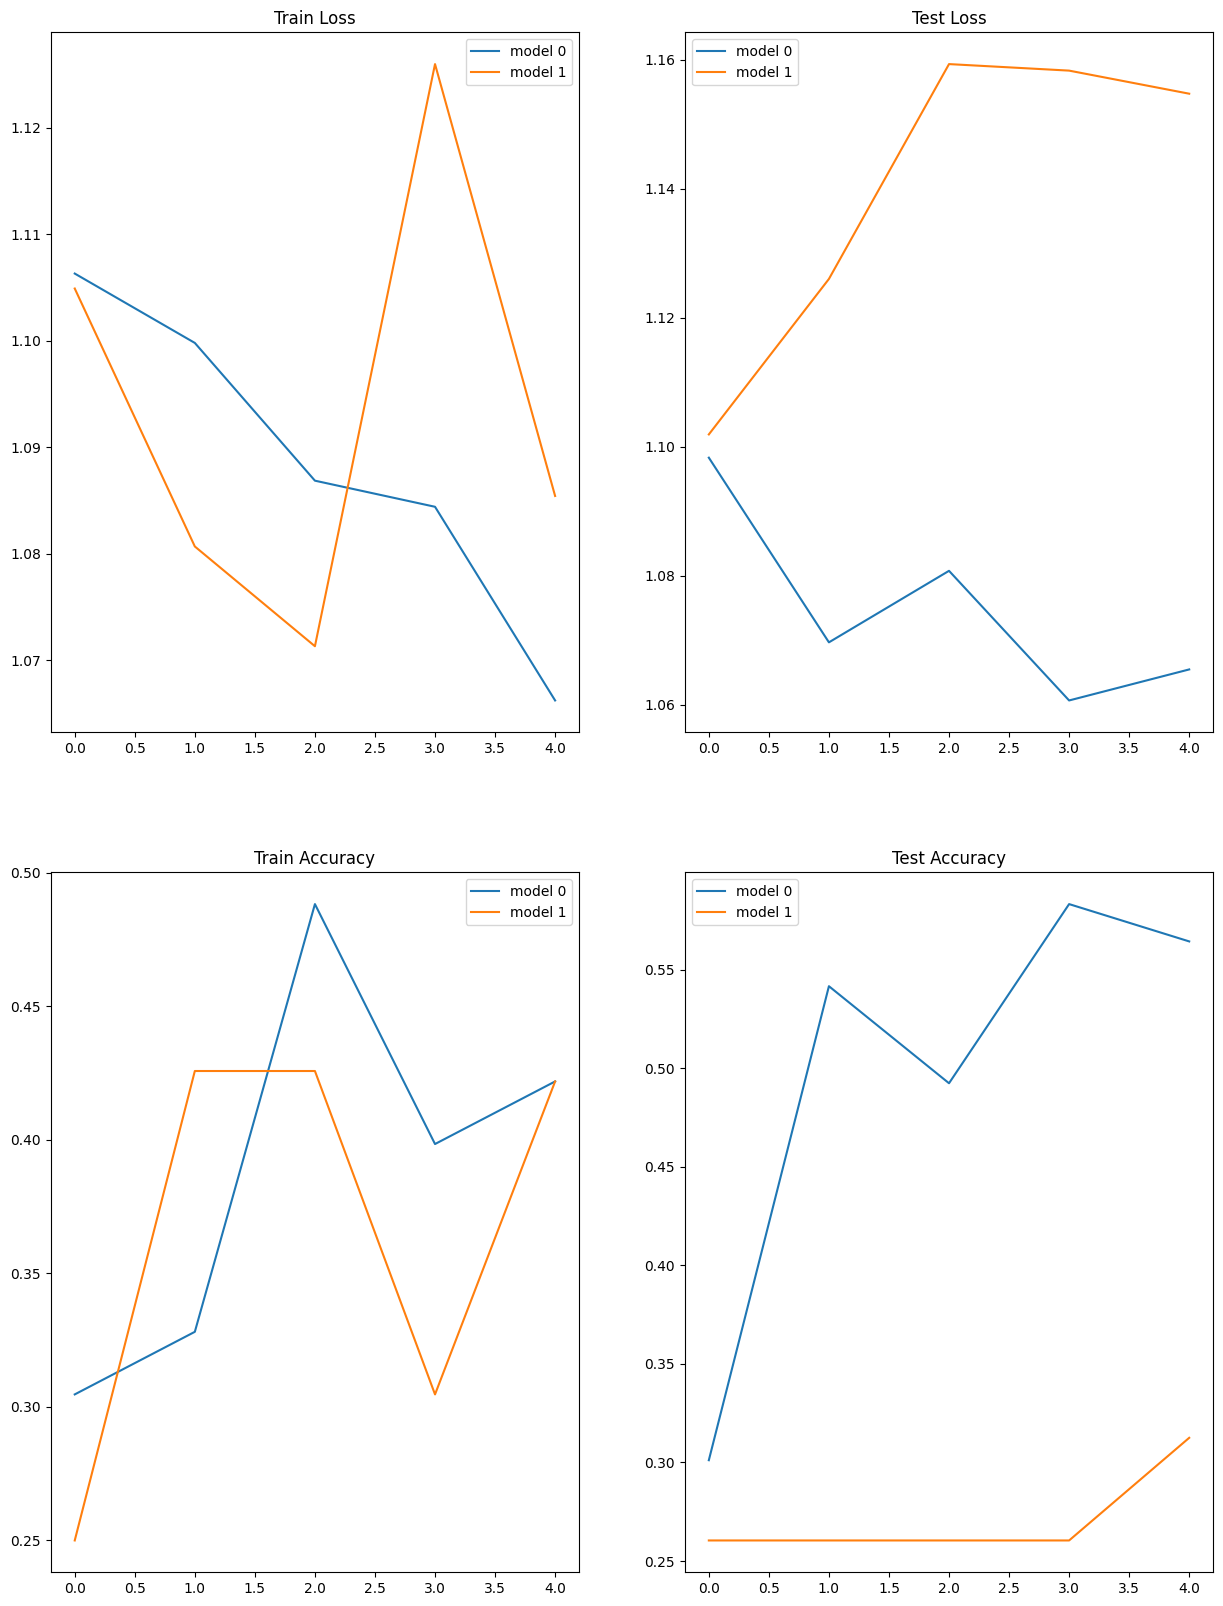

In [371]:
plt.figure(figsize=(15,20))

epochs = range(len(model_0_df))

plt.subplot(2,2,1)
plt.plot(epochs,model_0_df["train_loss"],label="model 0")
plt.plot(epochs,model_1_df["train_loss"],label="model 1")
plt.title("Train Loss")
plt.legend()

plt.subplot(2,2,2)
plt.plot(epochs,model_0_df["test_loss"],label="model 0")
plt.plot(epochs,model_1_df["test_loss"],label="model 1")
plt.title("Test Loss")
plt.legend()

plt.subplot(2,2,3)
plt.plot(epochs,model_0_df["train_acc"],label="model 0")
plt.plot(epochs,model_1_df["train_acc"],label="model 1")
plt.title("Train Accuracy")
plt.legend()

plt.subplot(2,2,4)
plt.plot(epochs,model_0_df["test_acc"],label="model 0")
plt.plot(epochs,model_1_df["test_acc"],label="model 1")
plt.title("Test Accuracy")
plt.legend()

# Predicting model over custom image

In [372]:
import requests
custom_image_path = data_path / "food3.jpeg"
if not custom_image_path.is_file():
  with open(custom_image_path,"wb") as f:
    request = requests.get("https://raw.githubusercontent.com/94Akriti/DL-ML-USING-PYTORCH/main/Data/food3.jpeg")
    print(f"Downloading file to {custom_image_path}.....")
    f.write(request.content)
else:
  print(f"{custom_image_path} already exists")

data/food3.jpeg already exists


In [373]:
custom_image_path

PosixPath('data/food3.jpeg')

In [374]:
import torchvision

custom_image_uint8 = torchvision.io.read_image(str(custom_image_path))

In [375]:
custom_image_uint8

tensor([[[30, 30, 31,  ..., 35, 35, 35],
         [30, 30, 31,  ..., 35, 35, 35],
         [31, 31, 31,  ..., 35, 35, 35],
         ...,
         [ 0,  0,  0,  ...,  6,  6,  6],
         [ 0,  0,  0,  ...,  6,  6,  6],
         [ 0,  0,  0,  ...,  6,  6,  6]],

        [[56, 56, 57,  ..., 56, 56, 56],
         [56, 56, 57,  ..., 56, 56, 56],
         [57, 57, 57,  ..., 56, 56, 56],
         ...,
         [ 9,  9,  9,  ..., 20, 20, 20],
         [ 9,  9,  9,  ..., 20, 20, 20],
         [ 9,  9,  9,  ..., 20, 20, 20]],

        [[93, 93, 94,  ..., 69, 69, 69],
         [93, 93, 94,  ..., 69, 69, 69],
         [94, 94, 94,  ..., 69, 69, 69],
         ...,
         [17, 17, 17,  ..., 32, 32, 32],
         [17, 17, 17,  ..., 32, 32, 32],
         [17, 17, 17,  ..., 32, 32, 32]]], dtype=torch.uint8)

In [376]:
custom_image_uint8.shape

torch.Size([3, 333, 500])

## Making prediction over trained PyTorch model

In [377]:
custom_image = (torchvision.io.read_image(str(custom_image_path)).type(torch.float32))/255
custom_image


tensor([[[0.1176, 0.1176, 0.1216,  ..., 0.1373, 0.1373, 0.1373],
         [0.1176, 0.1176, 0.1216,  ..., 0.1373, 0.1373, 0.1373],
         [0.1216, 0.1216, 0.1216,  ..., 0.1373, 0.1373, 0.1373],
         ...,
         [0.0000, 0.0000, 0.0000,  ..., 0.0235, 0.0235, 0.0235],
         [0.0000, 0.0000, 0.0000,  ..., 0.0235, 0.0235, 0.0235],
         [0.0000, 0.0000, 0.0000,  ..., 0.0235, 0.0235, 0.0235]],

        [[0.2196, 0.2196, 0.2235,  ..., 0.2196, 0.2196, 0.2196],
         [0.2196, 0.2196, 0.2235,  ..., 0.2196, 0.2196, 0.2196],
         [0.2235, 0.2235, 0.2235,  ..., 0.2196, 0.2196, 0.2196],
         ...,
         [0.0353, 0.0353, 0.0353,  ..., 0.0784, 0.0784, 0.0784],
         [0.0353, 0.0353, 0.0353,  ..., 0.0784, 0.0784, 0.0784],
         [0.0353, 0.0353, 0.0353,  ..., 0.0784, 0.0784, 0.0784]],

        [[0.3647, 0.3647, 0.3686,  ..., 0.2706, 0.2706, 0.2706],
         [0.3647, 0.3647, 0.3686,  ..., 0.2706, 0.2706, 0.2706],
         [0.3686, 0.3686, 0.3686,  ..., 0.2706, 0.2706, 0.

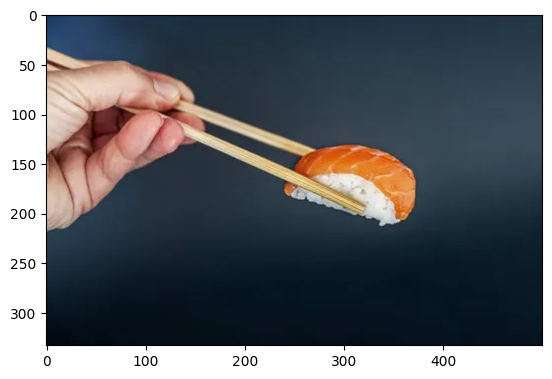

In [378]:
plt.imshow(custom_image.permute(1,2,0))


## Create Transform to resize our image for processing

In [379]:
from torchvision import transforms
custom_image_transform = transforms.Compose([
    transforms.Resize(size=(64,64))
])
custom_image_transformed = custom_image_transform(custom_image)
custom_image.shape,custom_image_transformed.shape

(torch.Size([3, 333, 500]), torch.Size([3, 64, 64]))

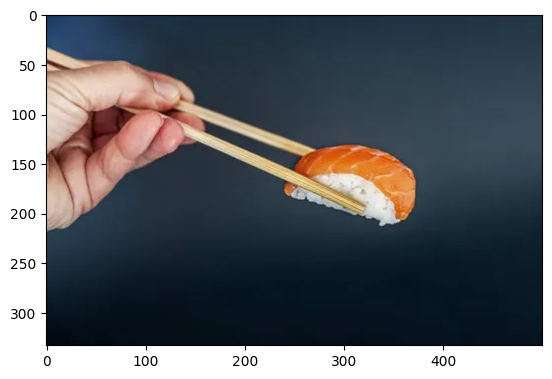

In [380]:
plt.imshow(custom_image.permute(1,2,0))

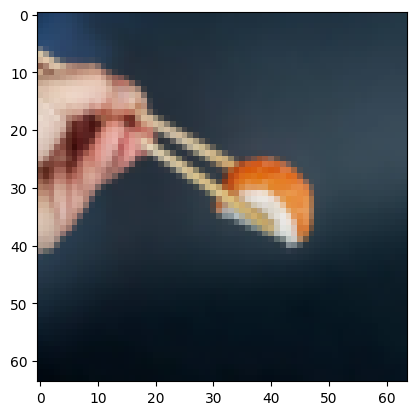

In [381]:
plt.imshow(custom_image_transformed.permute(1,2,0))

In [398]:
model_1.eval()
with torch.inference_mode():
  custom_image_pred = model_1(custom_image_transformed.unsqueeze(0).to(device))
custom_image_pred

tensor([[ 0.0641,  0.0548, -0.1927]], device='cuda:0')

In [399]:
# Convert logits to prediction probabilities

custom_image_pred_probs = torch.softmax(custom_image_pred,dim=1)
custom_image_pred_probs


tensor([[0.3617, 0.3584, 0.2798]], device='cuda:0')

In [400]:
custom_image_pred_labels = torch.argmax(custom_image_pred_probs,dim = 1).cpu()

In [401]:
class_names[custom_image_pred_labels]

'pizza'

## Build function for making prediction

In [404]:
def pred_and_plot_image(model: torch.nn.Module,
                        image_path: str,
                        class_names: List[str] = None,
                        transform = None,
                        device = device):
  # load image
  target_image = torchvision.io.read_image(str(image_path)).type(torch.float32)

  # image pixels modulation
  target_image = target_image / 255

  # transform image
  if transform:
    target_image = transform(target_image)

  #  change tensor dimensions to get same mat dimension as required in model
  target_image = target_image.unsqueeze(0)

  # set model to same device
  model.to(device)

  # turn on eval() and inference mode and make predictions
  model.eval()

  with torch.inference_mode():
    target_image_pred = model(target_image.to(device))

  # convert logits to prediction probability
  target_image_pred_probs = torch.softmax(target_image_pred,dim = 1)

  # Convert prediction probability to labels
  target_image_pred_label = torch.argmax(target_image_pred_probs,dim = 1)

  # plot the image
  plt.imshow(target_image.squeeze().permute(1,2,0)) # remove the etra batch added and rearrange thee image dimensions to HWC

  if class_names:
    title = f"Pred: {class_names[target_image_pred_label]} | Prob: {target_image_pred_probs.max():.3f}"
  else:
    title = f"{target_image_pred_label} | Pred: {target_image_pred_probs.max().cpu():.3f}"
  plt.title(title)
  plt.axis(False)

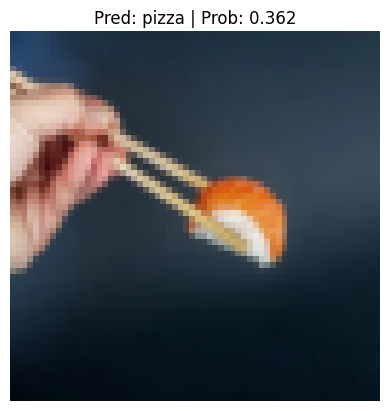

In [406]:
pred_and_plot_image(model_1,custom_image_path,class_names,transform = custom_image_transform,device = device)